# *G* por balanza de Cavendish — **medición 30**

Análisis no paramétrico. Tramos: **T3 sin masa**, **T4 con masa (6 cm)**, **T5 sin masa** (retorno).
Se muestra solo desde T3. $G=\kappa\,\Delta\theta/\tau_1$, con $\kappa=I\,\omega_0^2$; Δθ se corrige
por deriva con la baseline T3↔T5.

## ⚙️ Configuración
`MEDICIONES["medicion30"]`: `sin_masa`/`con_masa`/`sin_masa_2` = `dict(win, pico, desde, hasta)`;
`ring_down_win` (semilla del ajuste de κ); `d_cm_cm`. Incertezas: `SIG_D`, `SIG_R`, `SIG_MB`.

In [1]:
%matplotlib inline
import os, glob, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings("ignore")

# estilo simple y limpio
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.5,
})
C_T3, C_T4, C_T5 = "#2563eb", "#dc2626", "#16a34a"   # azul / rojo / verde

# =================== CONFIGURACIÓN ===================
BASE = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\Datos")
OUT  = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\Análisis")
FIGS = OUT / "figuras"; FIGS.mkdir(exist_ok=True)
CACHE = OUT / "_cache"; CACHE.mkdir(exist_ok=True)
USAR_CACHE = True
G_CODATA = 6.674e-11

FACTOR_ESPEJO = 2.0
LX_P, LY_P, LZ_P = 14.04e-2, 3.48e-2, 7e-2
R_BRAZO = 37e-2
MASA_PRISMA = 3.75
DENS_P = MASA_PRISMA / (LX_P * LY_P * LZ_P)
R_BOLA = 5.3e-2; M_BOLA = 4.6
N_GL = 12; INCLUIR_BRAZO_LEJANO = False
SEP_MIN_S = 60.0; VENTANA_EXTREMO_S = 5.0
SIG_D = 0.7e-2; SIG_R = 0.5e-2; SIG_MB = 0.05

MEDICIONES = {
    "medicion30": dict(rol="G", d_cm_cm=6e-2,
        sin_masa=dict(win=(5980, 8919),  pico="max", desde=4, hasta=8),    # T3 (estabilizado)
        con_masa=dict(win=(8919, 12803), pico="max", desde=3, hasta=10),   # T4 (bola a 6 cm)
        sin_masa_2=dict(win=(12803, 16441), pico="max", desde=3, hasta=9), # T5 (retorno sin masa)
        ring_down_win=(5980, 8919),                                        # semilla del ajuste (κ, β)
        nota="setup 2026-06-22; imanes; bola a 6 cm CM-CM"),
}
NOMBRE = "medicion30"
print("Config OK ->", NOMBRE)

Config OK -> medicion30


In [2]:
# =================== Lectura de datos ===================
def parse_meta(path):
    d = {}
    for ln in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        ln = ln.strip()
        if "\t" in ln and not ln.startswith("#"):
            k, v = ln.split("\t", 1); d[k] = v
    return d

def load_medicion(nombre, verbose=True):
    """Concatena chunks en orden temporal -> (t, x_mm, y_mm). Robusta a archivos malos;
    cose reinicios de cámara; cachea."""
    carpeta = BASE / nombre
    metas = glob.glob(str(carpeta / "*_meta.txt"))
    meta = parse_meta(metas[0]) if metas else {}
    L_mm = float(meta.get("distancia_a_la_pantalla (cm)", "nan")) * 10.0
    events = sorted(float(v) for k, v in meta.items() if re.match(r"masa_\d+_s$", k))
    cache = CACHE / f"{nombre}.npy"
    if USAR_CACHE and cache.exists():
        d = np.load(cache); t, x, y = d[0], d[1], d[2]
    else:
        archivos = sorted(glob.glob(str(carpeta / "*_[0-9][0-9][0-9][0-9].txt")),
                          key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
        if not archivos: raise FileNotFoundError(f"No hay chunks en {carpeta}")
        partes, malos = [], 0
        for f in archivos:
            try: a = pd.read_csv(f, sep="\t", header=None, dtype=float).values
            except Exception:
                try: a = np.atleast_2d(np.loadtxt(f))
                except Exception: malos += 1; continue
            if a.size and a.shape[1] >= 3: partes.append(np.atleast_2d(a[:, :3]))
            else: malos += 1
        datos = np.concatenate(partes, axis=0)
        t, x, y = datos[:, 0].copy(), datos[:, 1].copy(), datos[:, 2].copy()
        dd = np.diff(t); dt_med = np.median(dd[dd > 0]); saltos = np.flatnonzero(dd < 0)
        for j in saltos: t[j + 1:] += (t[j] - t[j + 1] + dt_med)
        if verbose:
            print(f"  [{nombre}] {len(archivos)} chunks, {len(t)} muestras, {malos} malos, "
                  f"{len(saltos)} reinicio(s) cosido(s)")
        np.save(cache, np.vstack([t, x, y]))
    return dict(nombre=nombre, t=t, x_mm=x, y_mm=y, L_mm=L_mm, events=events, meta=meta)

def a_rad(v_mm, L_mm):
    return np.arctan(v_mm / L_mm) / FACTOR_ESPEJO
print("I/O listo.")

I/O listo.


In [3]:
# =================== No paramétrico ===================
def cruces(t, x, nivel, sep_min_s=SEP_MIN_S):
    arr = x > nivel
    i = np.flatnonzero(arr[1:] != arr[:-1])
    if len(i) == 0: return np.array([]), np.array([], dtype=int)
    grupos = np.split(np.arange(len(i)), np.flatnonzero(np.diff(t[i]) > sep_min_s) + 1)
    tc, dc = [], []
    for g in grupos:
        if arr[i[g[0]]] == arr[i[g[-1]] + 1]: continue
        tc.append(float(t[i[g]].mean())); dc.append(+1 if arr[i[g[-1]] + 1] else -1)
    return np.array(tc), np.array(dc, dtype=int)

def extremos(ts, xs, t_cr, d_cr, v=VENTANA_EXTREMO_S):
    te, xe, tipo = [], [], []
    for i in range(len(t_cr) - 1):
        a, b = t_cr[i], t_cr[i + 1]; es_max = (d_cr[i] == +1)
        w = (ts >= a) & (ts <= b)
        if w.sum() < 10: continue
        tw, xw = ts[w], xs[w]; tg = np.arange(a + v, b - v + 1e-9, v)
        if len(tg) < 1:
            j = int(np.argmax(xw) if es_max else np.argmin(xw)); te.append(float(tw[j])); xe.append(float(xw[j]))
        else:
            md_ = np.array([np.median(xw[np.abs(tw - g) <= v]) for g in tg])
            j = int(np.argmax(md_) if es_max else np.argmin(md_)); te.append(float(tg[j])); xe.append(float(md_[j]))
        tipo.append(+1 if es_max else -1)
    return np.array(te), np.array(xe), np.array(tipo, dtype=int)

def extremos_tramo(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    return extremos(ts, xs, tc, dc)

def picos(te, xe, tipo, kind):
    m = tipo == (+1 if kind == "max" else -1)
    return te[m], xe[m]

def intervalo_por_picos(te, tipo, kind, desde, hasta):
    tk = picos(te, te, tipo, kind)[0]
    if len(tk) < hasta: return (tk[0] if len(tk) else np.nan), (tk[-1] if len(tk) else np.nan), len(tk)
    return float(tk[desde - 1]), float(tk[hasta - 1]), len(tk)

def periodo_tramo(t, th, win, modo="min"):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    if modo == "cruces":
        seps = np.concatenate([np.diff(tc[dc > 0]), np.diff(tc[dc < 0])])
    else:
        te, xe, tipo = extremos(ts, xs, tc, dc)
        sd = lambda k: np.diff(picos(te, te, tipo, k)[0])
        seps = np.concatenate([sd("min"), sd("max")]) if modo == "ambos" else sd(modo)
    if len(seps) == 0: return np.nan, np.nan, 0
    return float(np.median(seps)), (float(np.std(seps)) if len(seps) > 1 else np.nan), len(seps)

def midlines(te, xe, t_lo, t_hi):
    m = (te >= t_lo - 1e-6) & (te <= t_hi + 1e-6); tu, xu = te[m], xe[m]
    if len(xu) < 2: return np.array([]), np.array([])
    return 0.5 * (tu[1:] + tu[:-1]), 0.5 * (xu[1:] + xu[:-1])

def equilibrio_detrend(te, xe, t_lo, t_hi):
    """Equilibrio = midlines al centro del intervalo quitando deriva lineal; error = SEM del residuo."""
    tm, mids = midlines(te, xe, t_lo, t_hi)
    if len(mids) < 2: return (float(mids.mean()) if len(mids) else np.nan), np.nan, 0.0, tm, mids
    if len(mids) >= 3:
        p = np.polyfit(tm, mids, 1); resid = mids - np.polyval(p, tm)
        eq = float(np.polyval(p, tm.mean())); sem = float(resid.std(ddof=1) / np.sqrt(len(mids))); slope = float(p[0])
    else:
        eq = float(mids.mean()); sem = float(mids.std(ddof=1) / np.sqrt(len(mids))); slope = 0.0
    return eq, sem, slope, tm, mids

def spread_sub(te, xe, tipo, sel):
    """Dispersión del valor medio según el sub-intervalo elegido (sensibilidad, en grados)."""
    tk = picos(te, te, tipo, sel["pico"])[0][sel["desde"] - 1:sel["hasta"]]
    vals = []
    for a in range(len(tk)):
        for b in range(a + 1, len(tk)):
            tm, mids = midlines(te, xe, tk[a], tk[b])
            if len(mids) >= 1: vals.append(mids.mean())
    return float(np.std(vals)) if len(vals) > 1 else np.nan
print("No paramétrico listo.")

No paramétrico listo.


In [4]:
# =================== Ajuste amortiguado + búsqueda de la mejor ventana ===================
def modelo_amortiguado(t, eq, A, beta, wd, phi):
    return eq + A * np.exp(-beta * t) * np.cos(wd * t + phi)

def ajustar_amortiguado(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); tt = t[m] - t[m][0]; xx = th[m]
    eq0 = np.mean(xx); A0 = (xx.max() - xx.min()) / 2
    s = np.sign(xx - eq0); cr = tt[np.flatnonzero((s[:-1] < 0) & (s[1:] >= 0))]
    wd0 = 2 * np.pi / (np.median(np.diff(cr)) if len(cr) > 1 else tt[-1] / 4)
    h = len(xx) // 2
    Ai = (xx[:h].max() - xx[:h].min()) / 2; Af = (xx[h:].max() - xx[h:].min()) / 2
    beta0 = max(1e-5, np.log(max(Ai, 1e-9) / max(Af, 1e-9)) / (tt[-1] / 2))
    p0 = [eq0, A0, beta0, wd0, 0.0]
    bnd = ([eq0 - 1, 0, 0, wd0 * 0.5, -2*np.pi], [eq0 + 1, 5*A0, 1e-1, wd0 * 1.5, 2*np.pi])
    popt, pcov = curve_fit(modelo_amortiguado, tt, xx, p0=p0, bounds=bnd, maxfev=200000)
    eq, A, beta, wd, phi = popt; w0 = np.hypot(wd, beta)
    resid = xx - modelo_amortiguado(tt, *popt)
    return dict(eq=eq, A=A, beta=beta, wd=wd, phi=phi, w0=w0, rms=float(np.sqrt(np.mean(resid**2))),
                win=win, t0=t[m][0], tt=tt, xx=xx, fit=modelo_amortiguado(tt, *popt), resid=resid)

def mejor_ventana_ajuste(t, th, win0, n_pasos=10, frac_fin=0.92):
    """Busca la sub-ventana con menor residuo relativo (rms/A), saltando la 'patada' inicial."""
    a0, b0 = win0; b = a0 + frac_fin * (b0 - a0); paso = (b - a0) / (n_pasos + 4)
    cand = []
    for k in range(n_pasos):
        a = a0 + k * paso
        if b - a < 4 * paso: break
        try:
            f = ajustar_amortiguado(t, th, (a, b)); cand.append((f["rms"] / f["A"], f))
        except Exception: pass
    cand.sort(key=lambda z: z[0])
    return cand[0][1]
print("Ajuste listo.")

Ajuste listo.


In [5]:
# =================== Inercia, torque y propagación ===================
def I_colgado():
    m = DENS_P * LX_P * LY_P * LZ_P
    return 2 * (m / 12 * (LX_P**2 + LY_P**2) + m * R_BRAZO**2)
def kappa_de_w0(w0): return I_colgado() * w0**2

def torque_z(phi, R_arm, lp, dens_p, fuente, M, Gc, n_gl=N_GL):
    nodes, w = np.polynomial.legendre.leggauss(n_gl)
    hx, hy, hz = lp[0]/2, lp[1]/2, lp[2]/2
    U, V, Wz = np.meshgrid(hx*nodes, hy*nodes, hz*nodes, indexing="ij")
    WT = (w*hx)[:, None, None] * (w*hy)[None, :, None] * (w*hz)[None, None, :]
    c, s = np.cos(phi), np.sin(phi)
    xp = (U + R_arm)*c - V*s; yp = (U + R_arm)*s + V*c; zp = Wz
    xc, yc, zc = fuente; dx, dy, dz = xc - xp, yc - yp, zc - zp
    r = np.sqrt(dx*dx + dy*dy + dz*dz); f = Gc * M / r**3
    return float(np.sum((xp*(f*dy) - yp*(f*dx)) * dens_p * WT))

def tau_por_G(dtheta, d, R_arm=R_BRAZO, M=M_BOLA, n_gl=N_GL, ambos=INCLUIR_BRAZO_LEJANO):
    lp = (LX_P, LY_P, LZ_P); fuente = (R_arm, d, 0.0)
    tau = torque_z(dtheta, R_arm, lp, DENS_P, fuente, M, 1.0, n_gl)
    if ambos: tau += torque_z(dtheta + np.pi, R_arm, lp, DENS_P, fuente, M, 1.0, n_gl)
    return tau

def G_de(kappa, dtheta, d, R_arm=R_BRAZO, M=M_BOLA):
    dth = abs(dtheta); return kappa * dth / tau_por_G(dth, d, R_arm, M)

def propagar_G(kappa, dtheta, d, R_arm, M, sig):
    base = dict(kappa=kappa, dtheta=abs(dtheta), d=d, R_arm=R_arm, M=M)
    f = lambda **kw: G_de(kw["kappa"], kw["dtheta"], kw["d"], kw["R_arm"], kw["M"])
    G0 = f(**base); var = 0.0; contrib = {}
    for k, s in sig.items():
        if not s or base[k] == 0: contrib[k] = 0.0; continue
        hh = abs(base[k]) * 1e-4
        up = dict(base); up[k] += hh; dn = dict(base); dn[k] -= hh
        ci = ((f(**up) - f(**dn)) / (2*hh) * s)**2; contrib[k] = ci; var += ci
    return G0, np.sqrt(var), {k: (100*v/var if var > 0 else 0.0) for k, v in contrib.items()}
print(f"I_colgado = {I_colgado():.4f} kg·m²")

I_colgado = 1.0398 kg·m²


## 1) Señal (desde T3)

medicion30: 4.57 h  eventos=[5970, 5980, 8919, 12803] s


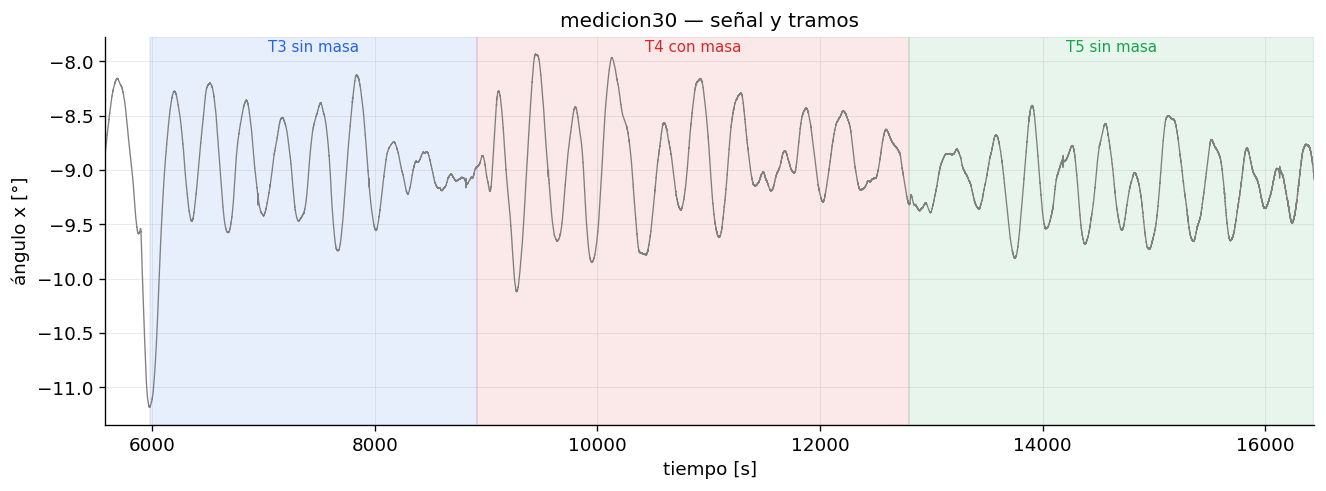

In [6]:
m = load_medicion(NOMBRE); th = a_rad(m["x_mm"], m["L_mm"]); t = m["t"]; ev = m["events"]
cfg = MEDICIONES[NOMBRE]
tramos = [("T3 sin masa", cfg["sin_masa"]["win"], C_T3), ("T4 con masa", cfg["con_masa"]["win"], C_T4),
          ("T5 sin masa", cfg["sin_masa_2"]["win"], C_T5)]
T0 = cfg["sin_masa"]["win"][0] - 400
mv = t >= T0
print(f"{NOMBRE}: {t[-1]/3600:.2f} h  eventos={[round(e) for e in ev]} s")

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.8, color="0.5")
for nom, (a, b), c in tramos:
    ax.axvspan(a, b, alpha=0.10, color=c)
    ax.text((a+b)/2, np.degrees(th[mv]).max(), nom, ha="center", va="bottom", fontsize=9, color=c)
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]")
ax.set_title(f"{NOMBRE} — señal y tramos"); fig.savefig(FIGS / "30_senal.png"); plt.show()

## 2) Constante de torsión κ (varios métodos)
$\kappa=I\,\omega_0^2$. Período por mín/máx/cruces (T3, T5) y ajuste amortiguado en el ring-down de
T3 (buscando la mejor sub-ventana). κ = mediana ± dispersión.

,metodo,T_s,kappa_Nm_rad
0,período mín,320.4,0.0003998
1,período máx,322.1,0.0003956
2,período cruces,324.3,0.0003904
3,ajuste,323.5,0.0003921


κ = 3.9387e-04 ± 3.6e-06 N·m/rad  (dispersión 0.9%)
ajuste: mejor ventana [7718,8684] s, T0=324 s, amortiguamiento (1+(β/ωd)²)=1.0241


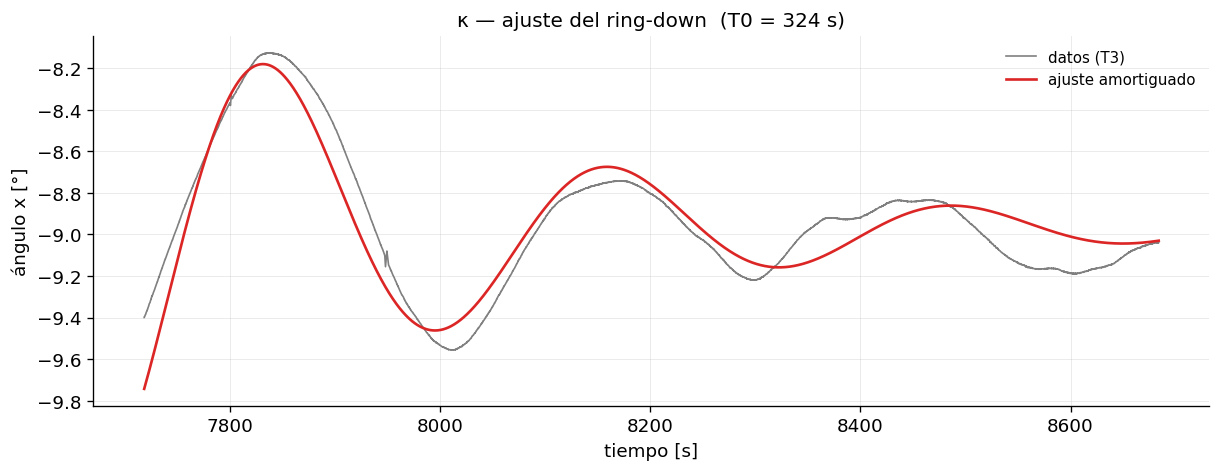

In [7]:
w3 = cfg["sin_masa"]["win"]; w5 = cfg["sin_masa_2"]["win"]
metodos = {}
for nom, modo in [("período mín", "min"), ("período máx", "max"), ("período cruces", "cruces")]:
    Ts = [periodo_tramo(t, th, w, modo)[0] for w in (w3, w5)]
    w0 = 2*np.pi / float(np.nanmean(Ts)); metodos[nom] = dict(T=2*np.pi/w0, kappa=kappa_de_w0(w0))
fit = mejor_ventana_ajuste(t, th, cfg["ring_down_win"])
metodos["ajuste"] = dict(T=2*np.pi/fit["w0"], kappa=kappa_de_w0(fit["w0"]))

df_k = pd.DataFrame([dict(metodo=k, T_s=round(v["T"], 1), kappa_Nm_rad=v["kappa"]) for k, v in metodos.items()])
pd.options.display.float_format = lambda v: f"{v:.4g}"
display(df_k)
kappas = np.array([v["kappa"] for v in metodos.values()])
kappa_30 = float(np.median(kappas)); kappa_30_err = float(np.std(kappas))
print(f"κ = {kappa_30:.4e} ± {kappa_30_err:.1e} N·m/rad  (dispersión {100*kappa_30_err/kappa_30:.1f}%)")
print(f"ajuste: mejor ventana [{fit['win'][0]:.0f},{fit['win'][1]:.0f}] s, T0={2*np.pi/fit['w0']:.0f} s, "
      f"amortiguamiento (1+(β/ωd)²)={1+(fit['beta']/fit['wd'])**2:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fit["t0"] + fit["tt"], np.degrees(fit["xx"]), lw=1.0, color="0.5", label="datos (T3)")
ax.plot(fit["t0"] + fit["tt"], np.degrees(fit["fit"]), color=C_T4, lw=1.6, label="ajuste amortiguado")
ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="upper right")
ax.set_title(f"κ — ajuste del ring-down  (T0 = {2*np.pi/fit['w0']:.0f} s)")
fig.savefig(FIGS / "30_kappa_ajuste.png"); plt.show()

## 3) Corrimiento del equilibrio Δθ
Equilibrio = valor medio entre extremos, quitando la deriva lineal de cada tramo. T3 y T5 dan la
baseline sin masa antes/después → $\Delta\theta=\mathrm{eq}(T4)-\mathrm{baseline}$.

  T3 sin masa: eq = -8.9894 ± 0.0323°   deriva -0.05 m°/s   sensib.±0.013°
  T4 con masa: eq = -8.9144 ± 0.0310°   deriva +0.08 m°/s   sensib.±0.052°
  T5 sin masa: eq = -9.1668 ± 0.0295°   deriva -0.06 m°/s   sensib.±0.036°

  retorno eq(T5)-eq(T3) = -0.1774° (el equilibrio NO vuelve: hay deriva)
  Δθ colocar=+0.0749°  sacar=+0.2524°  corregido=+0.1552°
  Δθ = +0.1552 ± 0.0379 (estad.) ± 0.0887 (deriva) °


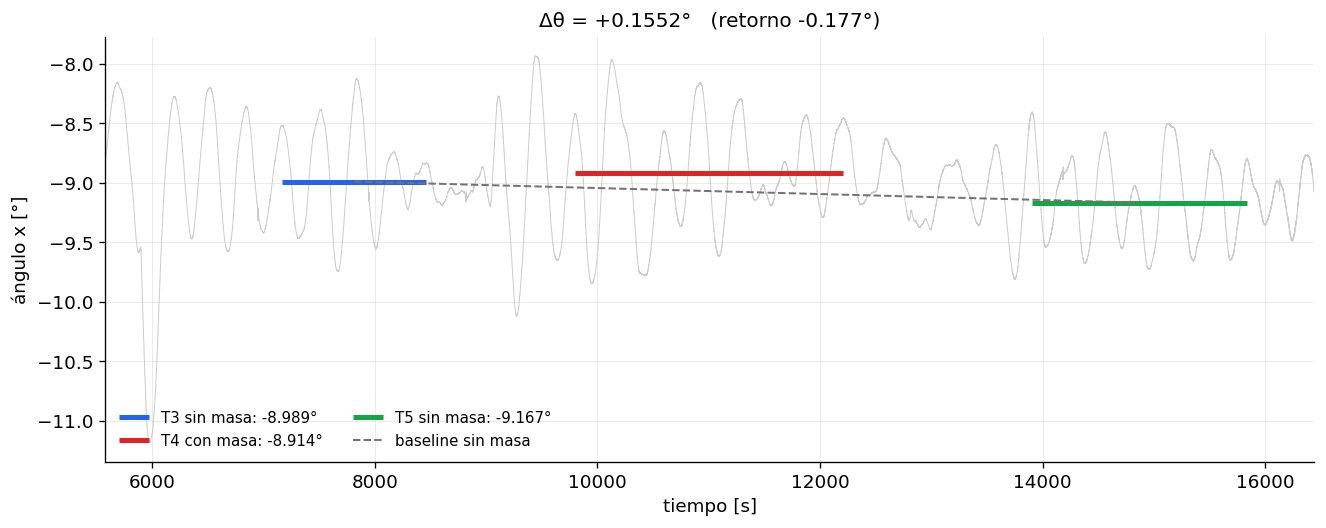

In [8]:
def analizar(sel, etq):
    te, xe, tipo = extremos_tramo(t, th, sel["win"])
    t_lo, t_hi, nd = intervalo_por_picos(te, tipo, sel["pico"], sel["desde"], sel["hasta"])
    eq, sem, slope, tm, mids = equilibrio_detrend(te, xe, t_lo, t_hi)
    spr = spread_sub(te, xe, tipo, sel)
    print(f"  {etq}: eq = {np.degrees(eq):+.4f} ± {np.degrees(sem):.4f}°   "
          f"deriva {np.degrees(slope)*1000:+.2f} m°/s   sensib.±{np.degrees(spr):.3f}°")
    return dict(eq=eq, sem=sem, t_lo=t_lo, t_hi=t_hi, tc=0.5*(t_lo+t_hi), tm=tm, mids=mids)

A = analizar(cfg["sin_masa"], "T3 sin masa")
B = analizar(cfg["con_masa"], "T4 con masa")
C = analizar(cfg["sin_masa_2"], "T5 sin masa")
base = float(np.interp(B["tc"], [A["tc"], C["tc"]], [A["eq"], C["eq"]]))
dth = dict(colocar=B["eq"]-A["eq"], sacar=B["eq"]-C["eq"], corregido=B["eq"]-base)
ret = C["eq"] - A["eq"]; dtheta = dth["corregido"]
dtheta_err = np.hypot(B["sem"], 0.5*np.hypot(A["sem"], C["sem"]))
dtheta_syst = 0.5*abs(dth["colocar"] - dth["sacar"])
print(f"\n  retorno eq(T5)-eq(T3) = {np.degrees(ret):+.4f}° (el equilibrio {'vuelve' if abs(ret)<abs(dth['colocar']) else 'NO vuelve: hay deriva'})")
print(f"  Δθ colocar={np.degrees(dth['colocar']):+.4f}°  sacar={np.degrees(dth['sacar']):+.4f}°  "
      f"corregido={np.degrees(dtheta):+.4f}°")
print(f"  Δθ = {np.degrees(dtheta):+.4f} ± {np.degrees(dtheta_err):.4f} (estad.) ± {np.degrees(dtheta_syst):.4f} (deriva) °")

mv = t >= T0
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.6, color="0.8")
for R, c, lab in [(A, C_T3, "T3 sin masa"), (B, C_T4, "T4 con masa"), (C, C_T5, "T5 sin masa")]:
    ax.hlines(np.degrees(R["eq"]), R["t_lo"], R["t_hi"], color=c, lw=3,
              label=f"{lab}: {np.degrees(R['eq']):.3f}°")
ax.plot([A["tc"], C["tc"]], np.degrees([A["eq"], C["eq"]]), "--", color="0.45", lw=1.2, label="baseline sin masa")
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]")
ax.set_title(f"Δθ = {np.degrees(dtheta):+.4f}°   (retorno {np.degrees(ret):+.3f}°)")
ax.legend(loc="lower left", ncol=2); fig.savefig(FIGS / "30_corrimiento.png"); plt.show()

## 4) Evolución del valor medio

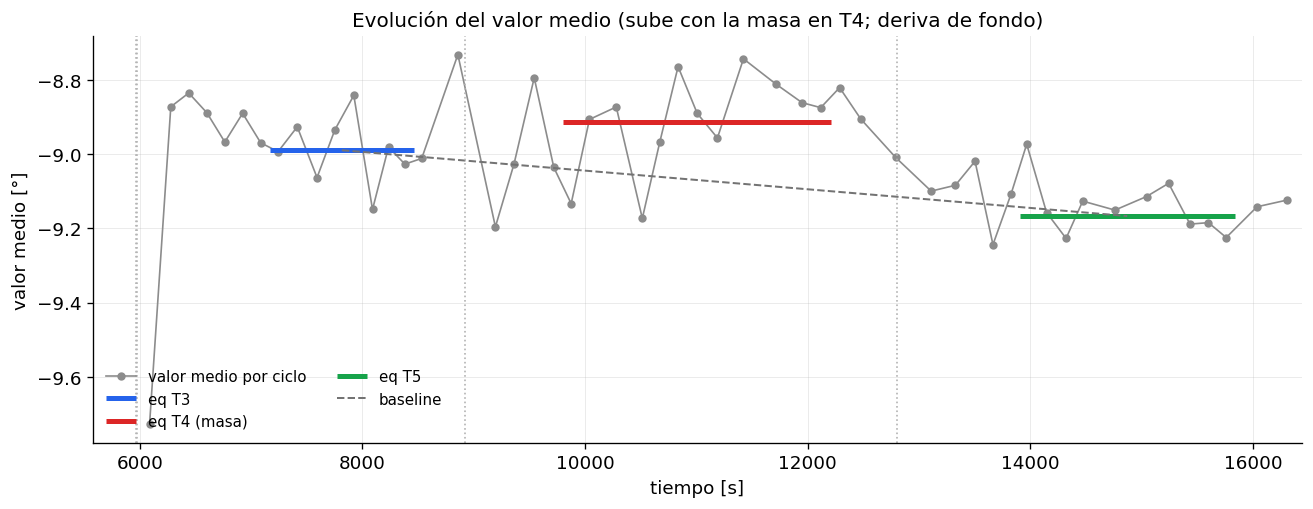

In [9]:
te_all, xe_all, tipo_all = extremos_tramo(t, th, (T0, t[-1]))
tm_all, mid_all = midlines(te_all, xe_all, T0, t[-1])
fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(tm_all, np.degrees(mid_all), "o-", ms=4, lw=1.0, color="0.55", label="valor medio por ciclo")
for R, c, lab in [(A, C_T3, "T3"), (B, C_T4, "T4 (masa)"), (C, C_T5, "T5")]:
    ax.hlines(np.degrees(R["eq"]), R["t_lo"], R["t_hi"], color=c, lw=3, label=f"eq {lab}")
ax.plot([A["tc"], C["tc"]], np.degrees([A["eq"], C["eq"]]), "--", color="0.45", lw=1.2, label="baseline")
for e in ev:
    if e >= T0: ax.axvline(e, color="0.7", ls=":", lw=1)
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("valor medio [°]")
ax.set_title("Evolución del valor medio (sube con la masa en T4; deriva de fondo)")
ax.legend(loc="lower left", ncol=2); fig.savefig(FIGS / "30_evolucion.png"); plt.show()

## 5) Comparación de análisis (tabla)

In [10]:
d = cfg["d_cm_cm"]
filas = [dict(kappa=nk, dtheta=nd_, G=G_de(vk["kappa"], vd, d), ratio=G_de(vk["kappa"], vd, d)/G_CODATA)
         for nk, vk in metodos.items() for nd_, vd in dth.items()]
tabla = pd.DataFrame(filas).pivot(index="kappa", columns="dtheta", values="ratio")[["colocar", "corregido", "sacar"]]
print("G / G_CODATA  para cada (método de κ) × (forma de Δθ):")
display(tabla.round(1))
print(f"\nLa forma de Δθ (deriva) manda: G/CODATA va de {tabla.values.min():.0f} a {tabla.values.max():.0f}.")
print(f"El método de κ casi no influye (±{100*kappa_30_err/kappa_30:.0f}%).")

G / G_CODATA  para cada (método de κ) × (forma de Δθ):


dtheta,colocar,corregido,sacar
kappa,,,
ajuste,7.2,14.8,23.8
período cruces,7.2,14.8,23.7
período máx,7.3,15,24
período mín,7.4,15.1,24.3



La forma de Δθ (deriva) manda: G/CODATA va de 7 a 24.
El método de κ casi no influye (±1%).


## 6) G final y cómo achicar el error

In [11]:
sig = dict(kappa=kappa_30_err, dtheta=dtheta_err, d=SIG_D, R_arm=SIG_R, M=SIG_MB)
G0, sG, pct = propagar_G(kappa_30, dtheta, d, R_BRAZO, M_BOLA, sig)
G_lo = G_de(kappa_30, dtheta - dtheta_syst, d); G_hi = G_de(kappa_30, dtheta + dtheta_syst, d)
print(f"G = ({G0:.2e} ± {sG:.1e}) m³ kg⁻¹ s⁻²   ->  {G0/G_CODATA:.1f}× CODATA   (σ estad. {100*sG/G0:.0f}%)")
print(f"con el sistemático de deriva: G ∈ [{G_lo:.2e}, {G_hi:.2e}]")
print("\nPeso en el error (estad.):", "  ".join(f"{k} {p:.0f}%" for k, p in sorted(pct.items(), key=lambda z:-z[1]) if p>0.5))
print("\nCómo achicar el error:")
print(f"  1) Deriva (lo que más pesa): el equilibrio no vuelve. Asentar más, estabilizar luz/temp,")
print(f"     y medir >=3 tramos sin masa para verificar/modelar la deriva.")
print(f"  2) d (G∝d²): σ_d={SIG_D*100:.1f} cm / {d*100:.0f} cm -> ~{100*2*SIG_D/d:.0f}% de G. Medir d a ±2 mm -> ~{100*2*0.002/d:.0f}%.")
print(f"  3) Más ciclos por tramo. κ ya está al {100*kappa_30_err/kappa_30:.0f}% (no limita).")

G = (9.94e-10 ± 2.8e-10) m³ kg⁻¹ s⁻²   ->  14.9× CODATA   (σ estad. 28%)
con el sistemático de deriva: G ∈ [4.31e-10, 1.54e-09]

Peso en el error (estad.): dtheta 72%  d 27%

Cómo achicar el error:
  1) Deriva (lo que más pesa): el equilibrio no vuelve. Asentar más, estabilizar luz/temp,
     y medir >=3 tramos sin masa para verificar/modelar la deriva.
  2) d (G∝d²): σ_d=0.7 cm / 6 cm -> ~23% de G. Medir d a ±2 mm -> ~7%.
  3) Más ciclos por tramo. κ ya está al 1% (no limita).


## 7) Resumen
- **κ** robusta (4 métodos al ~1 %): mejor ventana de ajuste saltea la "patada".
- **Δθ** corregido por deriva (baseline T3↔T5); el equilibrio **no vuelve**, así que queda un
  sistemático de deriva.
- **G** limitado por la deriva y por **d** (G∝d²). La sección 6 lista cómo bajarlo.